# NB17 — Cluster Stability Validation (Bootstrap)

## What does this notebook do?

In NB13 we grouped all 47 districts into 3 clusters using K-Means.
But K-Means just *finds* groups — it does not tell us whether those groups are **reliable**.

This notebook answers the question: **"If we slightly changed the data, would every district still end up in the same cluster?"**

We use a method called **Bootstrap Stability Testing**:
- We randomly pick 80% of districts (about 37 out of 47)
- We re-run K-Means on just those 37 districts
- We check: did each district land in the same cluster as before?
- We repeat this 200 times
- Each district gets a **stability score** = % of rounds it was correctly clustered

## How to read the results

| Stability Score | What it means |
|---|---|
| 90% or above | District is firmly placed — very trustworthy |
| 70% to 90%   | District is near a cluster boundary — mention as a caveat |
| Below 70%    | District is genuinely ambiguous — sits between two clusters |

**Input:**  `Data/Processed/env_features.csv`  
**Outputs:** `Data/Processed/bootstrap_stability.csv`, three plots saved as PNG files

In [1]:
# These are Python toolboxes we need for this notebook.
# Each one does a specific job:
#
#   os / warnings     → fix a harmless Windows warning that clutters the output
#   pandas            → work with tables (like Excel)
#   numpy             → do maths on arrays of numbers
#   matplotlib        → draw charts and plots
#   KMeans            → the clustering algorithm we used in NB13
#   StandardScaler    → scale features so they are comparable (same as NB12)
#   silhouette_samples→ measure how well each district fits its cluster (0 to 1)
#   linear_sum_assignment → the Hungarian algorithm (explained in Step 3)
# 

import os
import warnings

# This stops a noisy Windows warning about KMeans and memory threads.
# It is NOT an error — just a cosmetic fix so our output stays clean.
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.cluster       import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import silhouette_samples
from scipy.optimize        import linear_sum_assignment

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# Load the feature table (one row per district, 4 columns of data)

df = pd.read_csv("../Data/Processed/env_features.csv")

# The four features we used for clustering in NB13
FEATURES = ["fire_count", "residue", "avg_temp", "rainfall"]

# X  = the actual numbers (a 47 × 4 table of values)
# districts = list of district names in the same order
# N  = total number of districts (47)
# K  = number of clusters we chose in NB13 (3)
X         = df[FEATURES].values.astype(float)
districts = df["district"].values
N         = len(X)
K         = 3

print(f"Data loaded: {N} districts, {len(FEATURES)} features, {K} clusters")
print(f"Districts: {list(districts[:5])} ... (first 5 shown)")

Data loaded: 47 districts, 4 features, 3 clusters
Districts: ['Ambala', 'Amritsar', 'Barnala', 'Bathinda', 'Bhiwani'] ... (first 5 shown)


In [3]:
# Run the same K-Means as NB13 on ALL 47 districts.
# This gives us the 'ground truth' cluster labels.
# Every stability test will compare back to these labels.

# Step A: Scale the features (subtract mean, divide by std deviation)
# This makes fire_count, residue, temperature, and rainfall comparable
# because they are originally in very different units and ranges.
scaler_full   = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# Step B: Run K-Means with k=3
# random_state=42 means the starting point is fixed → same result every run
# n_init=15 means K-Means tries 15 different starting points and picks the best
kmeans_full = KMeans(n_clusters=K, random_state=42, n_init=15)
labels_full = kmeans_full.fit_predict(X_scaled_full)
# labels_full is now an array like [2, 1, 1, 0, 2, ...]
# telling us which cluster (0, 1, or 2) each district belongs to

# Step C: Compute silhouette score for each district
# Silhouette score = how well does this district fit its cluster?
#   Close to +1 → fits perfectly, far from other clusters
#   Close to  0 → sitting right on the boundary between two clusters
#   Negative    → might actually belong to a different cluster
sil_scores_full = silhouette_samples(X_scaled_full, labels_full)

print("Baseline clustering complete.")
print()
print("How many districts in each cluster:")
for cluster_id, count in pd.Series(labels_full).value_counts().sort_index().items():
    print(f"  Cluster {cluster_id}: {count} districts")
print()
print(f"Overall average silhouette score: {sil_scores_full.mean():.4f}")
print("(The closer to 1.0, the more distinct and well-separated the clusters are)")

Baseline clustering complete.

How many districts in each cluster:
  Cluster 0: 10 districts
  Cluster 1: 17 districts
  Cluster 2: 20 districts

Overall average silhouette score: 0.4088
(The closer to 1.0, the more distinct and well-separated the clusters are)


In [4]:
# This function takes:
#   original_labels → the cluster numbers from the full NB13 run
#   new_labels      → the cluster numbers from a bootstrap run
#   k               → number of clusters (3)
#
# It returns a dictionary like {0: 2, 1: 0, 2: 1} meaning:
#   'new cluster 0' is the same group as 'original cluster 2'
#   'new cluster 1' is the same group as 'original cluster 0'
#   'new cluster 2' is the same group as 'original cluster 1'
#
# We use this dictionary to translate every new prediction before comparing.

def align_cluster_labels(original_labels, new_labels, k):
    """
    Find the best matching between original cluster numbers and new cluster
    numbers so that comparisons between them are meaningful.
    Uses the Hungarian algorithm (linear_sum_assignment) internally.
    """

    # Convert inputs to numpy arrays just to be safe
    original_labels = np.asarray(original_labels)
    new_labels      = np.asarray(new_labels)

    # Build an overlap table (k × k):
    # overlap[i][j] = how many districts were in original cluster i
    #                 AND new cluster j at the same time?
    # Example: if 15 districts that were in original cluster 2
    #          ended up in new cluster 0 → overlap[2][0] = 15
    overlap = np.zeros((k, k), dtype=int)
    for orig_cluster in range(k):
        for new_cluster in range(k):
            overlap[orig_cluster, new_cluster] = int(
                np.sum(
                    (original_labels == orig_cluster) & (new_labels == new_cluster)
                )
            )

    # linear_sum_assignment finds the assignment that maximises total overlap
    # (we negate because it minimises by default, so -overlap = maximise overlap)
    row_ind, col_ind = linear_sum_assignment(-overlap)

    # Build the translation dictionary: {new_cluster_number: original_cluster_number}
    translation = {col_ind[r]: row_ind[r] for r in range(k)}
    return translation


# Quick self-test to confirm the function works correctly
# We set up a simple known example and check the answer

# Suppose original had: points in clusters [0, 0, 1, 1, 2, 2]
# New run named them: [2, 2, 0, 0, 1, 1]  (every cluster got a different number)
# The function should detect that new-0=original-1, new-1=original-2, new-2=original-0
test_original = np.array([0, 0, 1, 1, 2, 2])
test_new      = np.array([2, 2, 0, 0, 1, 1])
test_mapping  = align_cluster_labels(test_original, test_new, k=3)
test_fixed    = np.array([test_mapping[x] for x in test_new])

# After applying the mapping, test_fixed should exactly equal test_original
assert np.array_equal(test_fixed, test_original), "ERROR: label alignment function is broken!"
print(f"Label alignment function works correctly.")
print(f"Test mapping found: {test_mapping}")
print("(Meaning: new cluster 2 = original cluster 0, etc.)")

Label alignment function works correctly.
Test mapping found: {np.int64(2): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}
(Meaning: new cluster 2 = original cluster 0, etc.)


In [5]:
# ------------------------------------------------------------
# Bootstrap settings
# ------------------------------------------------------------

N_BOOT      = 200    # how many rounds to run
SAMPLE_FRAC = 0.80   # use 80% of districts each round
sample_size = int(np.floor(N * SAMPLE_FRAC))   # = 37 districts per round

# Two counters, one value per district (47 values each, all starting at 0)
# boot_hits[i]   = how many rounds district i was clustered correctly
# boot_counts[i] = how many rounds district i appeared in the sample at all
boot_hits   = np.zeros(N, dtype=int)
boot_counts = np.zeros(N, dtype=int)

# Random number generator with a fixed seed so results are reproducible
# (same seed = same 200 random samples every time you run this notebook)
rng = np.random.default_rng(seed=0)

print(f"Starting bootstrap: {N_BOOT} rounds, {sample_size} districts per round...")
print("This may take about 30-60 seconds. Please wait.")
print()

# ------------------------------------------------------------
# The main bootstrap loop
# ------------------------------------------------------------

for round_number in range(N_BOOT):

    # --- Pick 37 random district indices (no repeats in same round) -------
    selected_indices = rng.choice(N, size=sample_size, replace=False)

    # --- Grab the data rows and original labels for those 37 districts ----
    X_sample            = X[selected_indices]              # 37 rows of feature data
    original_labels_sample = labels_full[selected_indices] # their original cluster numbers

    # --- Scale ONLY these 37 districts ------------------------------------
    # Important: we do NOT use the full scaler from Step 2.
    # We fit a fresh scaler on just the 37 selected districts.
    # This prevents the removed districts from influencing the scaling.
    scaler_round = StandardScaler()
    X_sample_scaled = scaler_round.fit_transform(X_sample)

    # --- Run a fresh K-Means on the 37 scaled districts -------------------
    # We use round_number as the random seed so each round starts differently.
    # This tests whether the result depends on the random starting point too.
    km_round  = KMeans(n_clusters=K, random_state=round_number, n_init=10)
    new_labels = km_round.fit_predict(X_sample_scaled)
    # new_labels is an array like [1, 0, 2, 0, ...] for the 37 districts
    # but the numbers 0/1/2 might mean different groups than before!

    # --- Fix the label names using our alignment function -----------------
    # This finds the translation between new cluster numbers and original ones
    label_translation = align_cluster_labels(
        original_labels_sample, new_labels, k=K
    )

    # --- Score each district in this round --------------------------------
    for position, district_index in enumerate(selected_indices):
        # Translate the new raw label to the original cluster numbering
        corrected_label = label_translation[new_labels[position]]

        # Record that this district appeared in this round
        boot_counts[district_index] += 1

        # If the corrected label matches the original, count it as a hit
        if corrected_label == labels_full[district_index]:
            boot_hits[district_index] += 1


# ------------------------------------------------------------
# Calculate stability score for each district
# stability = hits / appearances (converted to percentage)
# np.where handles the edge case of a district never being sampled (rare)
# ------------------------------------------------------------
boot_stability_fraction = np.where(
    boot_counts > 0,
    boot_hits / boot_counts,
    np.nan   # NaN means 'not applicable' (district never appeared — very unlikely)
)

# ------------------------------------------------------------
# Build a results table with one row per district
# ------------------------------------------------------------
results_df = pd.DataFrame({
    'district'        : districts,
    'cluster'         : labels_full,          # original cluster number (0, 1, or 2)
    'silhouette_score': sil_scores_full,       # how well the district fits its cluster
    'stability_pct'   : (boot_stability_fraction * 100).round(1),  # stability as %
    'correct_rounds'  : boot_hits,             # out of how many appearances
    'total_rounds'    : boot_counts,           # total times district was in a sample
})

# Sort by stability (lowest first) so borderline districts appear at top
results_df = results_df.sort_values('stability_pct').reset_index(drop=True)

# Summary statistics
mean_stability = results_df['stability_pct'].mean()
min_stability  = results_df['stability_pct'].min()
max_stability  = results_df['stability_pct'].max()
worst_district = results_df.iloc[0]['district']

print(f"Bootstrap complete! ({N_BOOT} rounds finished)")
print()
print(f"Summary:")
print(f"  Average stability across all districts : {mean_stability:.1f}%")
print(f"  Most stable district (highest score)   : {results_df.iloc[-1]['district']} ({max_stability:.1f}%)")
print(f"  Least stable district (lowest score)   : {worst_district} ({min_stability:.1f}%)")
print()

# Count districts in each stability tier
firmly_placed = (results_df['stability_pct'] >= 90).sum()
borderline    = ((results_df['stability_pct'] >= 70) & (results_df['stability_pct'] < 90)).sum()
ambiguous     = (results_df['stability_pct'] < 70).sum()

print(f"Stability breakdown:")
print(f"  Firmly placed  (≥ 90%) : {firmly_placed} districts")
print(f"  Borderline  (70-90%)   : {borderline} districts")
print(f"  Ambiguous   (< 70%)    : {ambiguous} districts")
print()

# Show any borderline or ambiguous districts
flagged = results_df[results_df['stability_pct'] < 90]
if len(flagged) == 0:
    print("All districts scored 90% or above — excellent stability!")
else:
    print("Districts scoring below 90% (worth mentioning in the thesis):")
    print(
        flagged[['district', 'cluster', 'stability_pct', 'silhouette_score']]
        .to_string(index=False)
    )

Starting bootstrap: 200 rounds, 37 districts per round...
This may take about 30-60 seconds. Please wait.

Bootstrap complete! (200 rounds finished)

Summary:
  Average stability across all districts : 98.6%
  Most stable district (highest score)   : Muktsar (100.0%)
  Least stable district (lowest score)   : Hisar (76.5%)

Stability breakdown:
  Firmly placed  (≥ 90%) : 46 districts
  Borderline  (70-90%)   : 1 districts
  Ambiguous   (< 70%)    : 0 districts

Districts scoring below 90% (worth mentioning in the thesis):
district  cluster  stability_pct  silhouette_score
   Hisar        2           76.5         -0.076278


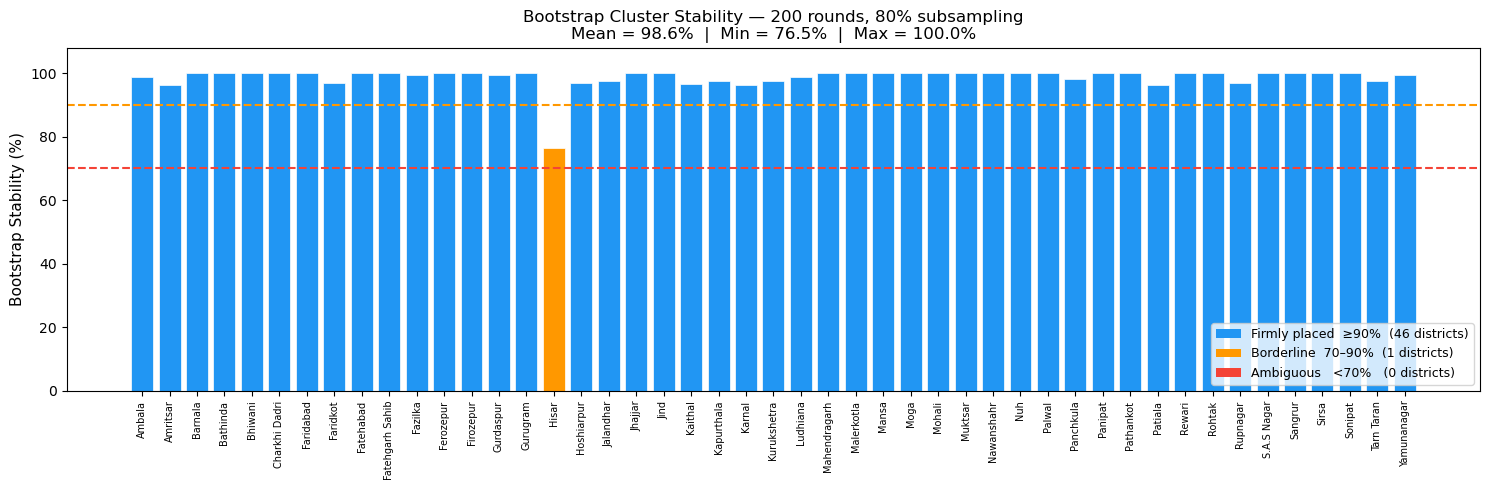

Bar chart saved.


In [6]:
# Helper function: assigns a colour based on stability percentage
def stability_colour(pct):
    if pct >= 90:
        return '#2196F3'   # blue = stable
    elif pct >= 70:
        return '#FF9800'   # orange = borderline
    else:
        return '#F44336'   # red = ambiguous

# Apply the colour function to every district's stability score
bar_colours = results_df['stability_pct'].apply(stability_colour)

# Sort by district name for the chart so it reads alphabetically
plot_df = results_df.sort_values('district')
plot_colours = plot_df['stability_pct'].apply(stability_colour)

# Create the bar chart
fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(
    plot_df['district'],    # x-axis: district names
    plot_df['stability_pct'], # y-axis: stability score
    color=plot_colours,
    edgecolor='white',
    linewidth=0.5
)

# Draw reference lines at 90% and 70% so tiers are clearly visible
ax.axhline(90, color='#FF9800', linewidth=1.5, linestyle='--', label='90% threshold (borderline)')
ax.axhline(70, color='#F44336', linewidth=1.5, linestyle='--', label='70% threshold (ambiguous)')

# Axis labels and title
ax.set_ylim(0, 108)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df['district'], rotation=90, fontsize=7)
ax.set_ylabel('Bootstrap Stability (%)', fontsize=11)
ax.set_title(
    f'Bootstrap Cluster Stability — {N_BOOT} rounds, {int(SAMPLE_FRAC*100)}% subsampling\n'
    f'Mean = {mean_stability:.1f}%  |  Min = {min_stability:.1f}%  |  Max = {max_stability:.1f}%',
    fontsize=12
)

# Legend explaining the colours
legend_items = [
    mpatches.Patch(facecolor='#2196F3', label=f'Firmly placed  ≥90%  ({firmly_placed} districts)'),
    mpatches.Patch(facecolor='#FF9800', label=f'Borderline  70–90%  ({borderline} districts)'),
    mpatches.Patch(facecolor='#F44336', label=f'Ambiguous   <70%   ({ambiguous} districts)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../Data/Processed/bootstrap_stability_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart saved.")

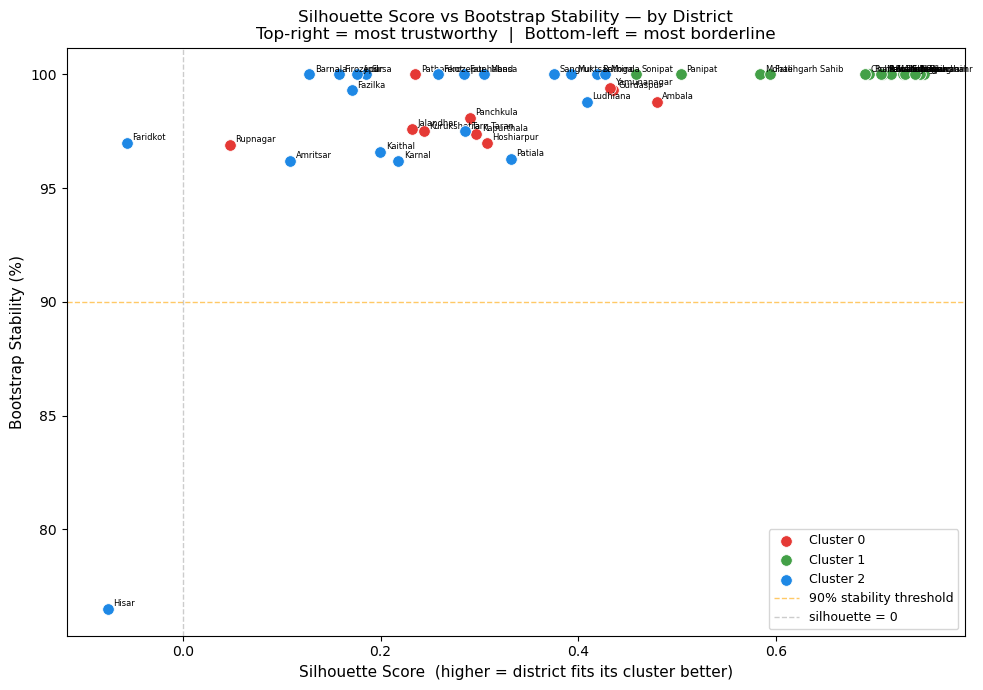

Scatter plot saved.


In [7]:
# Colour each dot by which cluster the district belongs to
cluster_colours = {0: '#E53935', 1: '#43A047', 2: '#1E88E5'}  # red, green, blue

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each cluster's districts as a separate group (so legend works)
for cluster_id in sorted(results_df['cluster'].unique()):

    # Get only the rows belonging to this cluster
    group = results_df[results_df['cluster'] == cluster_id]

    # Draw the dots
    ax.scatter(
        group['silhouette_score'],   # x position
        group['stability_pct'],      # y position
        c=cluster_colours.get(cluster_id, 'grey'),
        label=f'Cluster {cluster_id}',
        s=70,                        # dot size
        edgecolors='white',
        linewidths=0.6,
        zorder=3
    )

    # Add district name label next to each dot
    for _, row in group.iterrows():
        ax.annotate(
            row['district'],
            xy=(row['silhouette_score'], row['stability_pct']),
            fontsize=6,
            xytext=(4, 2),
            textcoords='offset points'
        )

# Reference lines
ax.axhline(90, color='orange', linewidth=1, linestyle='--', alpha=0.6, label='90% stability threshold')
ax.axvline(0,  color='grey',   linewidth=1, linestyle='--', alpha=0.4, label='silhouette = 0')

ax.set_xlabel('Silhouette Score  (higher = district fits its cluster better)', fontsize=11)
ax.set_ylabel('Bootstrap Stability (%)', fontsize=11)
ax.set_title(
    'Silhouette Score vs Bootstrap Stability — by District\n'
    'Top-right = most trustworthy  |  Bottom-left = most borderline',
    fontsize=12
)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../Data/Processed/stability_vs_silhouette_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved.")

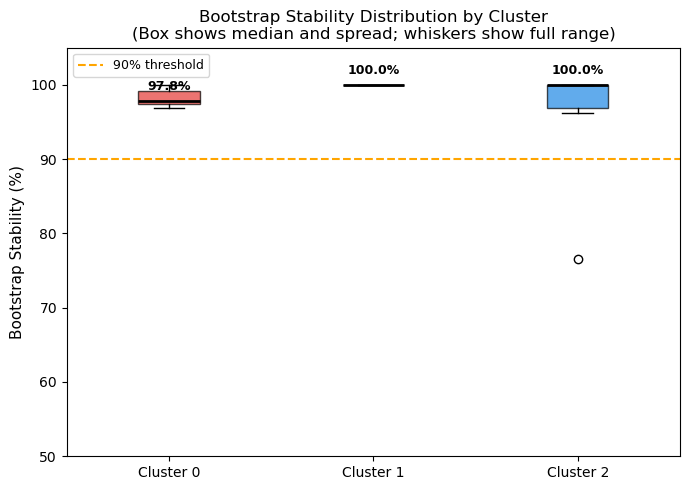

Box plot saved.


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

# Collect the stability scores for each cluster into separate lists
cluster_ids     = sorted(results_df['cluster'].unique())
data_per_cluster = [
    results_df[results_df['cluster'] == cid]['stability_pct'].values
    for cid in cluster_ids
]

# Draw box plots (shows median, spread, and outliers)
bp = ax.boxplot(
    data_per_cluster,
    tick_labels=[f'Cluster {cid}' for cid in cluster_ids],
    patch_artist=True,    # filled boxes, not just outlines
    medianprops=dict(color='black', linewidth=2)
)

# Colour each box by cluster
box_colours = ['#E53935', '#43A047', '#1E88E5']
for patch, colour in zip(bp['boxes'], box_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)

# Reference line at 90%
ax.axhline(90, color='orange', linewidth=1.5, linestyle='--', label='90% threshold')

ax.set_ylim(50, 105)
ax.set_ylabel('Bootstrap Stability (%)', fontsize=11)
ax.set_title(
    'Bootstrap Stability Distribution by Cluster\n'
    '(Box shows median and spread; whiskers show full range)',
    fontsize=12
)

# Print median for each cluster next to the plot title
for i, cid in enumerate(cluster_ids):
    median_val = np.median(data_per_cluster[i])
    ax.text(i + 1, median_val + 1.5, f'{median_val:.1f}%',
            ha='center', fontsize=9, fontweight='bold')

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../Data/Processed/bootstrap_stability_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plot saved.")

In [9]:
# Add a plain-English confidence label to each district
# so the saved CSV is easy to read and use in the dissertation

def confidence_label(pct):
    if pct >= 90:
        return 'High'      # firmly placed in its cluster
    elif pct >= 70:
        return 'Moderate'  # near a cluster boundary
    else:
        return 'Low'       # genuinely ambiguous

results_df['confidence'] = results_df['stability_pct'].apply(confidence_label)

# Sort alphabetically by district name for the saved file
results_df = results_df.sort_values('district').reset_index(drop=True)

# Print the full results table
print("=" * 65)
print("FULL BOOTSTRAP STABILITY RESULTS — ALL 47 DISTRICTS")
print("=" * 65)
print(
    results_df[['district', 'cluster', 'stability_pct',
                'silhouette_score', 'correct_rounds', 'total_rounds', 'confidence']]
    .to_string(index=False)
)

print()
print("=" * 65)
print("INTERPRETATION FOR DISSERTATION")
print("=" * 65)
print()
print(
    f"The K-Means clustering (k=3) was validated using bootstrap "
    f"subsampling ({N_BOOT} rounds, {int(SAMPLE_FRAC*100)}% of districts sampled "
    f"per round). The mean stability across all {N} districts was "
    f"{mean_stability:.1f}%, indicating that the cluster structure is "
    f"robust to random data variation. "
    f"{firmly_placed} of {N} districts ({firmly_placed/N*100:.0f}%) achieved "
    f"high stability (≥90%), confirming that the three intervention zones "
    f"identified in NB13 are statistically reliable."
)

if borderline > 0 or ambiguous > 0:
    flagged_names = results_df[results_df['confidence'] != 'High']['district'].tolist()
    print()
    print(
        f"Note: {borderline + ambiguous} district(s) scored below 90% — "
        f"{', '.join(flagged_names)}. These districts sit near cluster "
        f"boundaries and their assignments should be treated with caution."
    )

FULL BOOTSTRAP STABILITY RESULTS — ALL 47 DISTRICTS
       district  cluster  stability_pct  silhouette_score  correct_rounds  total_rounds confidence
         Ambala        0           98.8          0.479628             166           168       High
       Amritsar        2           96.2          0.108330             152           158       High
        Barnala        2          100.0          0.127900             145           145       High
       Bathinda        2          100.0          0.418762             158           158       High
        Bhiwani        1          100.0          0.749858             161           161       High
  Charkhi Dadri        1          100.0          0.690667             157           157       High
      Faridabad        1          100.0          0.731126             158           158       High
       Faridkot        2           97.0         -0.057157             159           164       High
      Fatehabad        2          100.0          0.284346

In [10]:
# Save the results table as a CSV file
# This file can be opened in Excel and attached as an appendix

save_cols = [
    'district',        # district name
    'cluster',         # which cluster (0, 1, or 2) from NB13
    'stability_pct',   # bootstrap stability score (%)
    'silhouette_score',# how well district fits its cluster (-1 to +1)
    'correct_rounds',  # how many rounds it was clustered correctly
    'total_rounds',    # how many rounds it appeared in
    'confidence',      # High / Moderate / Low
]

results_df[save_cols].to_csv('../Data/Processed/bootstrap_stability.csv', index=False)

print("Results saved successfully.")
print()
print("Files created:")
print("  ../Data/Processed/bootstrap_stability.csv          — full results table")
print("  ../Data/Processed/bootstrap_stability_barchart.png — bar chart")
print("  ../Data/Processed/stability_vs_silhouette_scatter.png — scatter plot")
print("  ../Data/Processed/bootstrap_stability_by_cluster.png  — box plot")
print()
print(f"Bootstrap stability mean : {mean_stability:.2f}%")
print(f"Bootstrap stability range: {min_stability:.1f}% to {max_stability:.1f}%")
print(f"High confidence districts: {firmly_placed} / {N}")

Results saved successfully.

Files created:
  ../Data/Processed/bootstrap_stability.csv          — full results table
  ../Data/Processed/bootstrap_stability_barchart.png — bar chart
  ../Data/Processed/stability_vs_silhouette_scatter.png — scatter plot
  ../Data/Processed/bootstrap_stability_by_cluster.png  — box plot

Bootstrap stability mean : 98.65%
Bootstrap stability range: 76.5% to 100.0%
High confidence districts: 46 / 47
